# Analysing Data
Notebook to run analysis on various output data for the ZdZd analysis:
- ZdZd13TeV `.root` files (Nominal/llllTree TTrees — primary BDT input)
- ZdZdPostProcessing `.root` files (TH1 histograms — final SR yields)

Mirrors the sections in `analyse_data_for_bdt.py` but with matplotlib plots.

In [1]:
import os
import sys
from collections import defaultdict

import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [2]:
# Import the analyse_data_for_bdt.py module from the parent directory
import importlib
imported_module = importlib.import_module("analyse_data_for_bdt")
importlib.reload(imported_module)

# Help check you are using the latest version
import analyse_data_for_bdt as ana_data
ana_data.test_func()

analyse_data_for_bdt version: 1.0


## Paths

In [3]:
BASE = os.path.dirname(os.path.abspath("analyse_data.ipynb"))

DATA_13TEV = {
    "mc23a_mZd30": os.path.join(BASE, "../data/example_data/ZdZd13TeV/mc23a_mZd30/my.output.root"),
    "mc23a_mZd60": os.path.join(BASE, "../data/example_data/ZdZd13TeV/mc23a_mZd60/my.output.root"),
}
DATA_PP = {
    "mc23a_mZd30": os.path.join(BASE, "../data/example_data/ZdZdPostProcessing/mc23a_mZd30/myfile.root"),
    "mc23a_mZd60": os.path.join(BASE, "../data/example_data/ZdZdPostProcessing/mc23a_mZd60/myfile.root"),
}

# Quick existence check
for label, path in {**DATA_13TEV, **DATA_PP}.items():
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}]  {label}: {path}")

  [OK]  mc23a_mZd30: /Users/matt/Documents/work/0-PhD/particle/xxzx-analysis/code_ZdZd/git_Zd/ZdZd-repos/run3_ZdZd_project/tmva_ZdZd_R3/../data/example_data/ZdZdPostProcessing/mc23a_mZd30/myfile.root
  [OK]  mc23a_mZd60: /Users/matt/Documents/work/0-PhD/particle/xxzx-analysis/code_ZdZd/git_Zd/ZdZd-repos/run3_ZdZd_project/tmva_ZdZd_R3/../data/example_data/ZdZdPostProcessing/mc23a_mZd60/myfile.root


## Helper functions

In [4]:
def first_quad(arr, mask):
    """Return the first quadruplet per event for events passing mask."""
    return ak.to_numpy(arr[mask][:, 0])

In [5]:
ana_data.section_13tev_structure()


SECTION 1: ZdZd13TeV output – file/tree structure

[mc23a_mZd30]  /Users/matt/Documents/work/0-PhD/particle/xxzx-analysis/code_ZdZd/git_Zd/ZdZd-repos/run3_ZdZd_project/tmva_ZdZd_R3/../data/example_data/ZdZd13TeV/mc23a_mZd30/my.output.root
  Top-level directories (systematic variants): 57
    Nominal  +  56 systematic variations
    Systematics: EG_RESOLUTION_ALL1down, EG_RESOLUTION_ALL1up, EG_SCALE_ALL1down, EG_SCALE_ALL1up, JET_EtaIntercalibration_NonClosure_Pre...
  Other top-level objects: ['Nominal', 'EG_RESOLUTION_ALL1up', 'EG_RESOLUTION_ALL1down', 'EG_SCALE_ALL1up', 'EG_SCALE_ALL1down', 'MUONS_CB1up', 'MUONS_CB1down', 'MUONS_SCALE1up', 'MUONS_SCALE1down', 'MUONS_SAGITTA_DATASTAT1up', 'MUONS_SAGITTA_DATASTAT1down', 'MUONS_SAGITTA_RESBIAS1up', 'MUONS_SAGITTA_RESBIAS1down', 'MUONS_SAGITTA_GLOBAL1up', 'MUONS_SAGITTA_GLOBAL1down', 'MUONS_SAGITTA_PTEXTRA1up', 'MUONS_SAGITTA_PTEXTRA1down', 'JET_GroupedNP_11up', 'JET_GroupedNP_11down', 'JET_GroupedNP_21up', 'JET_GroupedNP_21down', 'JET_

---
## Section 1 — ZdZd13TeV tree structure

In [20]:
label, path = next(iter(DATA_13TEV.items()))  # show once — structure is identical across samples
print(f"[{label}]  {path}")

with uproot.open(path) as f:
    all_keys = f.keys()

    # Top-level directories = systematic variations
    dirs = sorted({k.split("/")[0].rstrip(";1") for k in all_keys if "/" in k})
    print(f"  Nominal + {len(dirs)-1} systematic variations")
    print(f"  Systematics (first 10): {dirs[1:11]}")

    # Nominal tree in detail
    tree = f["Nominal/llllTree"]
    keys = tree.keys()
    scalar = [k for k in keys if not tree[k].interpretation.__class__.__name__.startswith("AsJagged")]
    jagged = [k for k in keys if tree[k].interpretation.__class__.__name__.startswith("AsJagged")]

    print(f"\n  Nominal/llllTree:")
    print(f"    Entries (events): {tree.num_entries}")
    print(f"    Branches:         {len(keys)}  (scalar: {len(scalar)}, jagged: {len(jagged)})")

    # Classify jagged by collection prefix
    prefixes = ["truth_l_", "truth_ll_", "truth_llll_",
                "hard_l_", "hard_ll_",
                "l_", "ll_", "llll_", "j_"]
    prefix_counts = defaultdict(list)
    unclassified = []
    for b in jagged:
        for p in prefixes:
            if b.startswith(p):
                prefix_counts[p].append(b)
                break
        else:
            unclassified.append(b)

    print("\n  Jagged branches by collection:")
    for p, blist in prefix_counts.items():
        names = ", ".join(b[len(p):] for b in blist[:8])
        extra = f" (+{len(blist)-8} more)" if len(blist) > 8 else ""
        print(f"    {p:<20} {len(blist):3d} branches   [{names}{extra}]")

[mc23a_mZd30]  /Users/matt/Documents/work/0-PhD/particle/xxzx-analysis/code_ZdZd/git_Zd/ZdZd-repos/run3_ZdZd_project/tmva_ZdZd_R3/../data/example_data/ZdZd13TeV/mc23a_mZd30/my.output.root
  Nominal + 56 systematic variations
  Systematics (first 10): ['EG_RESOLUTION_ALL1up', 'EG_SCALE_ALL1down', 'EG_SCALE_ALL1up', 'JET_EtaIntercalibration_NonClosure_PreRec1down', 'JET_EtaIntercalibration_NonClosure_PreRec1up', 'JET_GroupedNP_11down', 'JET_GroupedNP_11up', 'JET_GroupedNP_21down', 'JET_GroupedNP_21up', 'JET_GroupedNP_31down']

  Nominal/llllTree:
    Entries (events): 60000
    Branches:         250  (scalar: 52, jagged: 198)

  Jagged branches by collection:
    truth_l_               5 branches   [tlv_pt, tlv_eta, tlv_phi, pdgId, from_photon]
    l_                    18 branches   [truthType, truthOrigin, tlv_pt, tlv_eta, tlv_phi, pdgId, d0Sig, type (+10 more)]
    hard_l_                4 branches   [tlv_pt, tlv_eta, tlv_phi, pdgId]
    truth_ll_              8 branches   [tlv_pt, tl

---
## Section 2 — ZdZdPostProcessing file structure

[mc23a_mZd30]  /Users/matt/Documents/work/0-PhD/particle/xxzx-analysis/code_ZdZd/git_Zd/ZdZd-repos/run3_ZdZd_project/tmva_ZdZd_R3/../data/example_data/ZdZdPostProcessing/mc23a_mZd30/myfile.root
  Regions:  ['SR_2e2m', 'SR_4e', 'SR_4m', 'VR1_4e', 'VR1_4m', 'VR2_4e', 'VR2_4m', 'VR3_2e2m', 'VR3_4e', 'VR3_4m']
  MC channels: ['_5615']
  Systematics: 26


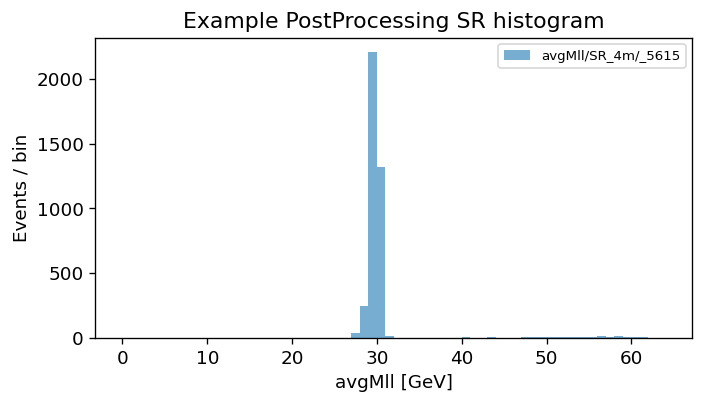

  Integral: 3897.6856


In [21]:
label, path = next(iter(DATA_PP.items()))
print(f"[{label}]  {path}")

with uproot.open(path) as f:
    all_keys = f.keys()
    regions, systs, channels = set(), set(), set()
    for k in all_keys:
        parts = k.rstrip(";1").split("/")
        if len(parts) >= 2:
            regions.add(parts[1])
        if len(parts) == 4:
            systs.add(parts[2])
        if len(parts) >= 3 and parts[-1].startswith("_"):
            channels.add(parts[-1])

    print(f"  Regions:  {sorted(regions)}")
    print(f"  MC channels: {sorted(channels)}")
    print(f"  Systematics: {len(systs)}")

    # Example SR histogram
    sr_key = next(
        k for k in all_keys
        if "SR_4m" in k and k.count("/") == 2 and "up" not in k and "down" not in k
    )
    h = f[sr_key]
    vals, edges = h.to_numpy()
    centres = 0.5 * (edges[:-1] + edges[1:])

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.stairs(vals, edges, fill=True, alpha=0.6, label=sr_key.rstrip(";1"))
    ax.set_xlabel("avgMll [GeV]")
    ax.set_ylabel("Events / bin")
    ax.set_title("Example PostProcessing SR histogram")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f"  Integral: {vals.sum():.4f}")

---
## Section 3 — Key distributions in ZdZd13TeV Nominal trees

In [22]:
BRANCHES = [
    "passCleaning", "passNPV", "passTriggers", "llll_n",
    "evtWeight", "PileupWeight", "mc_channel_number",
    "truth_zdzd_avgM",
    "l_tlv_pt", "l_tlv_eta", "l_pdgId", "l_quality",
    "ll_tlv_m",
    "llll_tlv_m", "llll_avgM", "llll_dM",
    "llll_pdgIdSum", "llll_charge", "llll_dCharge",
    "llll_overlaps", "llll_nCTorSA", "llll_triggerMatched",
    "llll_min_sf_dR", "llll_min_of_dR",
    "llll_max_el_d0Sig", "llll_max_mu_d0Sig",
    "llll_l_isIsolCloseBy",
    "llll_ll1", "llll_ll2", "llll_alt_ll1", "llll_alt_ll2",
    "llll_vtx_reduced_chi2",
    "llll_l1", "llll_l2", "llll_l3", "llll_l4",
]

datasets = {}  # label -> dict of arrays

for label, path in DATA_13TEV.items():
    with uproot.open(path) as f:
        tree = f["Nominal/llllTree"]
        data = tree.arrays(BRANCHES)
        datasets[label] = data
        print(f"[{label}]  {tree.num_entries} events loaded")

[mc23a_mZd30]  60000 events loaded
[mc23a_mZd60]  27707 events loaded


### 3a. Event-level preselection

In [23]:
for label, data in datasets.items():
    N = len(data["passCleaning"])
    n_clean = int(ak.sum(data["passCleaning"]))
    n_npv   = int(ak.sum(data["passNPV"] & data["passCleaning"]))
    n_trig  = int(ak.sum((data["passTriggers"] != 0) & data["passNPV"] & data["passCleaning"]))
    n_quad  = int(ak.sum(data["llll_n"] > 0))
    print(f"\n[{label}]  total events: {N}")
    print(f"  passCleaning:        {n_clean:6d} / {N}  ({100*n_clean/N:.1f}%)")
    print(f"  + passNPV:           {n_npv:6d} / {N}  ({100*n_npv/N:.1f}%)")
    print(f"  + passTriggers != 0: {n_trig:6d} / {N}  ({100*n_trig/N:.1f}%)")
    print(f"  events with llll_n>0:{n_quad:6d} / {N}  ({100*n_quad/N:.1f}%)")


[mc23a_mZd30]  total events: 60000
  passCleaning:         60000 / 60000  (100.0%)
  + passNPV:            60000 / 60000  (100.0%)
  + passTriggers != 0:  51707 / 60000  (86.2%)
  events with llll_n>0: 23526 / 60000  (39.2%)

[mc23a_mZd60]  total events: 27707
  passCleaning:         27707 / 27707  (100.0%)
  + passNPV:            27707 / 27707  (100.0%)
  + passTriggers != 0:  27269 / 27707  (98.4%)
  events with llll_n>0: 27115 / 27707  (97.9%)


### 3b. Object multiplicities

In [24]:
for label, data in datasets.items():
    print(f"\n[{label}]")
    for arr, name in [
        (ak.to_numpy(ak.num(data["l_tlv_pt"])),  "leptons (l)"),
        (ak.to_numpy(ak.num(data["ll_tlv_m"])),  "dileptons (ll)"),
        (ak.to_numpy(data["llll_n"]),             "quadruplets (llll)"),
    ]:
        unique, counts = np.unique(arr, return_counts=True)
        dist = ", ".join(f"n={u}: {c}" for u, c in zip(unique, counts))
        print(f"  {name:<25}: {dist}")


[mc23a_mZd30]
  leptons (l)              : n=0: 35895, n=4: 13006, n=5: 5718, n=6: 2688, n=7: 1277, n=8: 647, n=9: 357, n=10: 168, n=11: 107, n=12: 57, n=13: 30, n=14: 29, n=15: 11, n=16: 6, n=17: 3, n=18: 1
  dileptons (ll)           : n=0: 35897, n=1: 169, n=2: 11196, n=3: 460, n=4: 12115, n=5: 10, n=6: 147, n=7: 1, n=8: 3, n=9: 2
  quadruplets (llll)       : n=0: 36474, n=1: 10962, n=2: 12397, n=3: 3, n=4: 1, n=6: 157, n=12: 4, n=18: 2

[mc23a_mZd60]
  leptons (l)              : n=4: 15071, n=5: 6554, n=6: 3049, n=7: 1527, n=8: 725, n=9: 367, n=10: 183, n=11: 100, n=12: 53, n=13: 38, n=14: 21, n=15: 7, n=16: 5, n=17: 2, n=18: 2, n=19: 1, n=20: 2
  dileptons (ll)           : n=1: 211, n=2: 13193, n=3: 490, n=4: 13615, n=5: 8, n=6: 185, n=7: 1, n=8: 3, n=9: 1
  quadruplets (llll)       : n=0: 592, n=1: 12969, n=2: 13943, n=3: 3, n=4: 2, n=6: 193, n=12: 4, n=18: 1


### 3c. Lepton kinematics

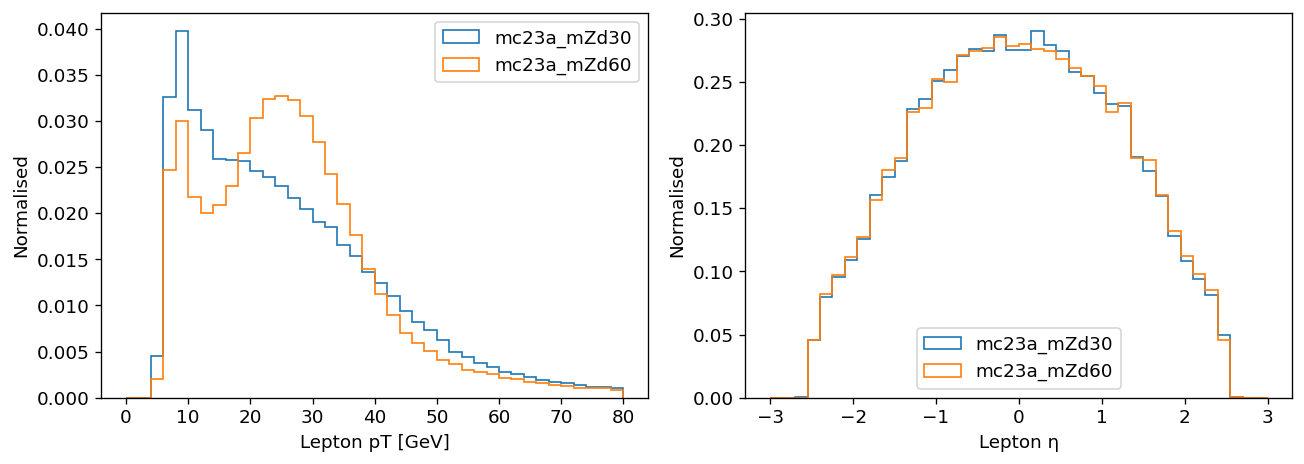

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, data in datasets.items():
    l_pt  = ak.to_numpy(ak.flatten(data["l_tlv_pt"])) / 1000.0
    l_eta = ak.to_numpy(ak.flatten(data["l_tlv_eta"]))
    axes[0].hist(l_pt,  bins=40, range=(0, 80),  histtype="step", label=label, density=True)
    axes[1].hist(l_eta, bins=40, range=(-3, 3),  histtype="step", label=label, density=True)

axes[0].set_xlabel("Lepton pT [GeV]"); axes[0].set_ylabel("Normalised")
axes[1].set_xlabel("Lepton η");         axes[1].set_ylabel("Normalised")
for ax in axes:
    ax.legend()
plt.tight_layout(); plt.show()

### 3d. Dilepton masses

  [mc23a_mZd30] m_ll: n=73382, min=0.0192, mean=38.3, median=30.3, max=622 GeV
  [mc23a_mZd60] m_ll: n=83717, min=0.00314, mean=52.2, median=58.9, max=449 GeV


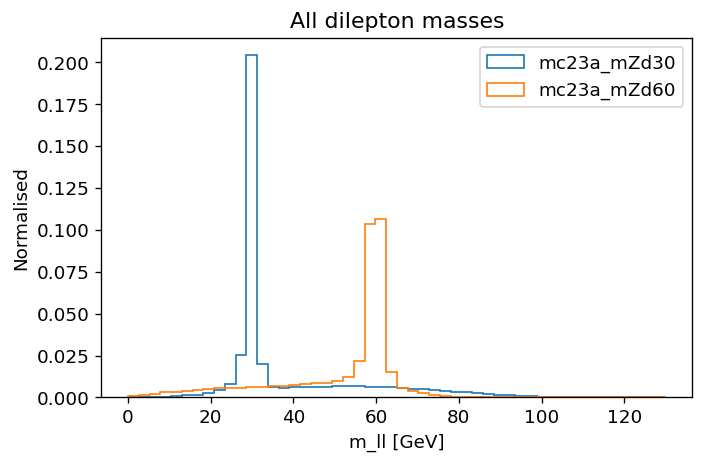

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, data in datasets.items():
    ll_m = ak.to_numpy(ak.flatten(data["ll_tlv_m"])) / 1000.0
    ax.hist(ll_m, bins=50, range=(0, 130), histtype="step", label=label, density=True)
    ana_data.stats(ll_m, f"[{label}] m_ll", "GeV")

ax.set_xlabel("m_ll [GeV]")
ax.set_ylabel("Normalised")
ax.set_title("All dilepton masses")
ax.legend()
plt.tight_layout(); plt.show()

### 3e. Selected quadruplet (llll[0]) properties

In [28]:
quad_data = {}  # label -> dict of derived arrays

for label, data in datasets.items():
    mask = data["llll_n"] > 0

    q_m4l  = first_quad(data["llll_tlv_m"],   mask) / 1000.0
    q_avgM = first_quad(data["llll_avgM"],     mask) / 1000.0
    q_dM   = first_quad(data["llll_dM"],       mask) / 1000.0

    # Dilepton masses via index lookup
    ll_m_sel = data["ll_tlv_m"][mask]
    q_ll1 = ak.to_numpy(data["llll_ll1"][mask][:, 0])
    q_ll2 = ak.to_numpy(data["llll_ll2"][mask][:, 0])

    m12 = np.array([float(ll_m_sel[i][q_ll1[i]]) for i in range(len(q_ll1))]) / 1000.0
    m34 = np.array([float(ll_m_sel[i][q_ll2[i]]) for i in range(len(q_ll2))]) / 1000.0
    mab = np.maximum(m12, m34)
    mcd = np.minimum(m12, m34)

    quad_data[label] = dict(m4l=q_m4l, avgM=q_avgM, dM=q_dM, mab=mab, mcd=mcd)

    print(f"\n[{label}]  events with ≥1 quadruplet: {int(ak.sum(mask))}")
    ana_data.stats(q_m4l,  "m_4l",            "GeV")
    ana_data.stats(mab,    "mab (leading ll)", "GeV")
    ana_data.stats(mcd,    "mcd (sub ll)",     "GeV")
    ana_data.stats(q_avgM, "avgM",             "GeV")
    ana_data.stats(q_dM,   "ΔM",               "GeV")


[mc23a_mZd30]  events with ≥1 quadruplet: 23526
  m_4l: n=23526, min=31.8, mean=123, median=124, max=324 GeV
  mab (leading ll): n=23526, min=12.2, mean=30.8, median=30.3, max=125 GeV
  mcd (sub ll): n=23526, min=0.0195, mean=29.2, median=29.5, max=74 GeV
  avgM: n=23526, min=6.16, mean=30, median=29.9, max=77.7 GeV
  ΔM: n=23526, min=0.000209, mean=1.64, median=0.889, max=95.8 GeV

[mc23a_mZd60]  events with ≥1 quadruplet: 27115
  m_4l: n=27115, min=14.3, mean=123, median=124, max=262 GeV
  mab (leading ll): n=27115, min=3.7, mean=59.5, median=60.4, max=182 GeV
  mcd (sub ll): n=27115, min=0.0592, mean=56.3, median=58.8, max=69.8 GeV
  avgM: n=27115, min=3.01, mean=57.9, median=59.5, max=121 GeV
  ΔM: n=27115, min=0.000145, mean=3.19, median=1.76, max=121 GeV


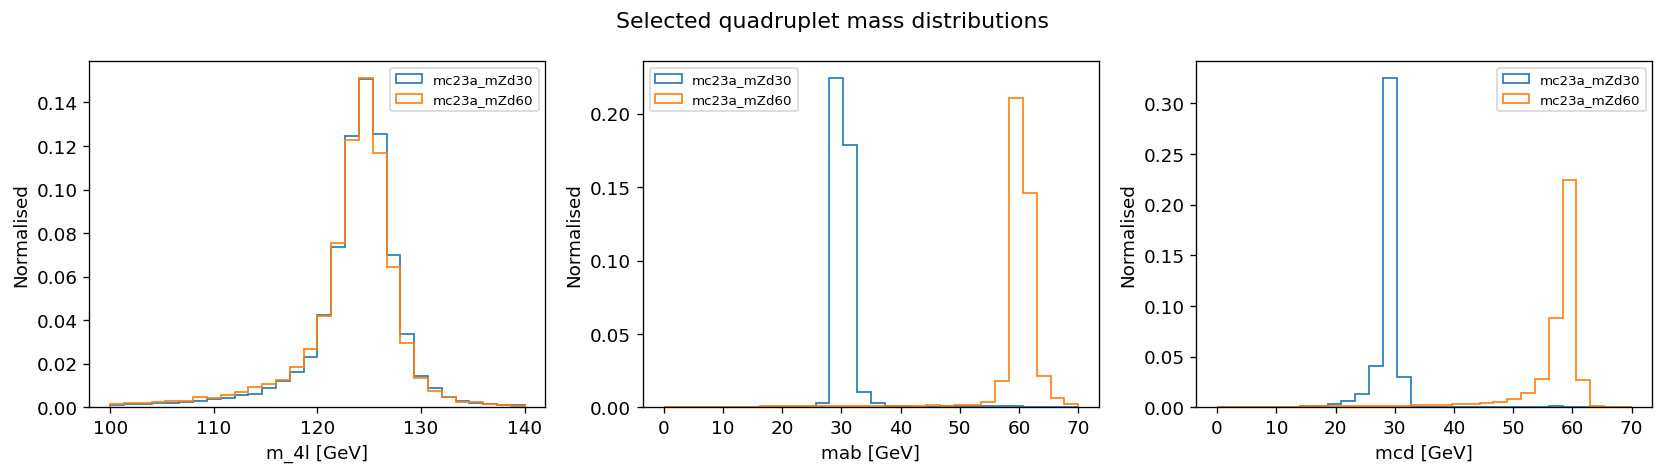

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    ("m4l",  "m_4l [GeV]",  (100, 140)),
    ("mab",  "mab [GeV]",   (0, 70)),
    ("mcd",  "mcd [GeV]",   (0, 70)),
]
for ax, (key, xlabel, rng) in zip(axes, configs):
    for label, qd in quad_data.items():
        ax.hist(qd[key], bins=30, range=rng, histtype="step", label=label, density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalised")
    ax.legend(fontsize=8)
plt.suptitle("Selected quadruplet mass distributions")
plt.tight_layout(); plt.show()

### 3f. Cutflow flags for selected quadruplet

In [30]:
for label, data in datasets.items():
    mask = data["llll_n"] > 0
    q_pdg  = first_quad(data["llll_pdgIdSum"],        mask)
    q_chr  = first_quad(data["llll_charge"],           mask)
    q_dchr = first_quad(data["llll_dCharge"],          mask)
    q_ovlp = first_quad(data["llll_overlaps"],         mask)
    q_trig = first_quad(data["llll_triggerMatched"],   mask)
    q_isol = first_quad(data["llll_l_isIsolCloseBy"], mask)
    q_ncto = first_quad(data["llll_nCTorSA"],          mask)
    q_sfdr = first_quad(data["llll_min_sf_dR"],        mask)
    q_ofdr = first_quad(data["llll_min_of_dR"],        mask)
    q_eld0 = first_quad(data["llll_max_el_d0Sig"],     mask)
    q_mud0 = first_quad(data["llll_max_mu_d0Sig"],     mask)

    print(f"\n[{label}]")
    for pdg, lbl in {44: "4e", 48: "2e2mu", 52: "4mu"}.items():
        print(f"  pdgIdSum={pdg} ({lbl:<5}): {np.mean(q_pdg==pdg)*100:.1f}%")
    print(f"  charge==0 & dCharge==0 (SFOS):   {np.mean((q_chr==0)&(q_dchr==0))*100:.1f}%")
    print(f"  overlaps & 0x36 == 0 (no OR):    {np.mean((q_ovlp & 54)==0)*100:.1f}%")
    print(f"  triggerMatched != 0:              {np.mean(q_trig!=0)*100:.1f}%")
    print(f"  l_isIsolCloseBy == 15:            {np.mean(q_isol==15)*100:.1f}%")
    print(f"  nCTorSA < 2:                      {np.mean(q_ncto<2)*100:.1f}%")
    print(f"  min_sf_dR > 0.1:                  {np.mean(q_sfdr>0.1)*100:.1f}%")
    print(f"  min_of_dR > 0.2:                  {np.mean(q_ofdr>0.2)*100:.1f}%")
    print(f"  max_el_d0Sig < 5:                 {np.mean(q_eld0<5)*100:.1f}%")
    print(f"  max_mu_d0Sig < 3:                 {np.mean(q_mud0<3)*100:.1f}%")


[mc23a_mZd30]
  pdgIdSum=44 (4e   ): 16.4%
  pdgIdSum=48 (2e2mu): 47.9%
  pdgIdSum=52 (4mu  ): 35.7%
  charge==0 & dCharge==0 (SFOS):   100.0%
  overlaps & 0x36 == 0 (no OR):    100.0%
  triggerMatched != 0:              97.0%
  l_isIsolCloseBy == 15:            82.2%
  nCTorSA < 2:                      99.9%
  min_sf_dR > 0.1:                  99.9%
  min_of_dR > 0.2:                  99.9%
  max_el_d0Sig < 5:                 99.7%
  max_mu_d0Sig < 3:                 98.2%

[mc23a_mZd60]
  pdgIdSum=44 (4e   ): 17.7%
  pdgIdSum=48 (2e2mu): 49.1%
  pdgIdSum=52 (4mu  ): 33.2%
  charge==0 & dCharge==0 (SFOS):   100.0%
  overlaps & 0x36 == 0 (no OR):    99.9%
  triggerMatched != 0:              98.0%
  l_isIsolCloseBy == 15:            83.6%
  nCTorSA < 2:                      99.9%
  min_sf_dR > 0.1:                  99.3%
  min_of_dR > 0.2:                  96.9%
  max_el_d0Sig < 5:                 99.6%
  max_mu_d0Sig < 3:                 98.4%


### 3g. Lepton pTs inside selected quadruplet

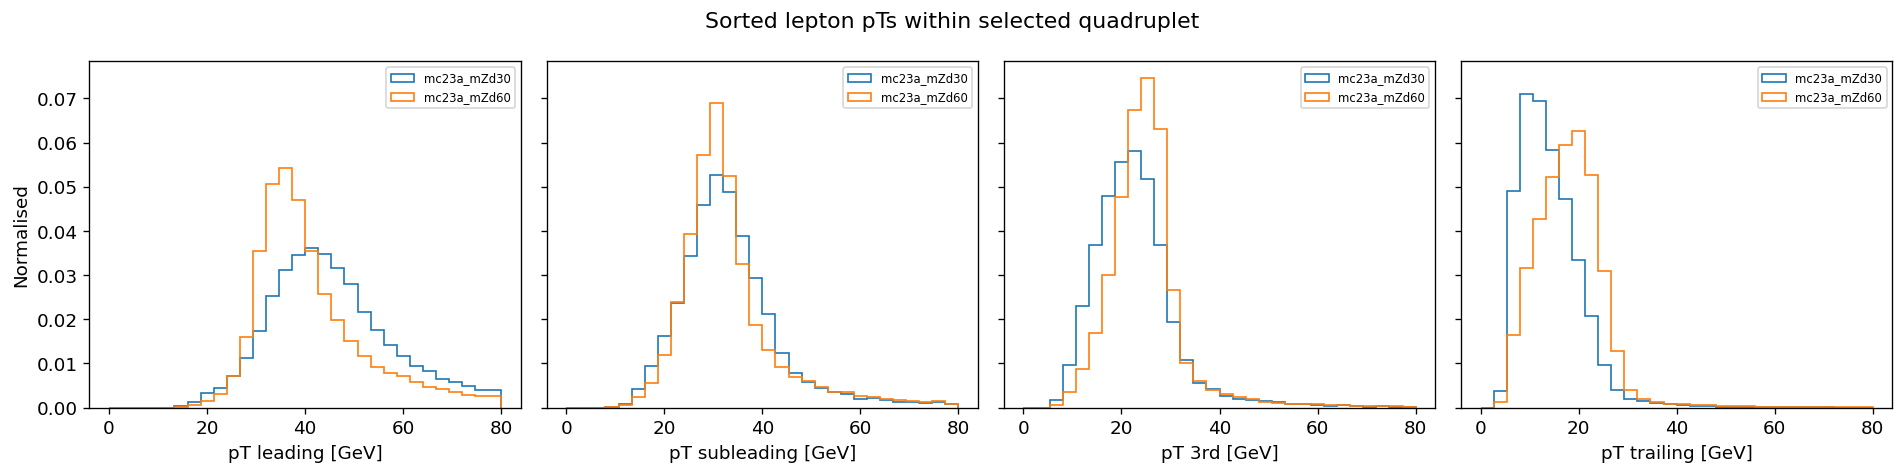

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
ranks = ["leading", "subleading", "3rd", "trailing"]

for label, data in datasets.items():
    mask = data["llll_n"] > 0
    l_pt_sel = data["l_tlv_pt"][mask]
    pts = []
    for li in ["llll_l1", "llll_l2", "llll_l3", "llll_l4"]:
        idx = ak.to_numpy(data[li][mask][:, 0])
        pts.append(np.array([float(l_pt_sel[i][idx[i]]) for i in range(len(idx))]) / 1000.0)

    pts_sorted = np.sort(np.column_stack(pts), axis=1)[:, ::-1]
    for i, (ax, rank) in enumerate(zip(axes, ranks)):
        ax.hist(pts_sorted[:, i], bins=30, range=(0, 80), histtype="step", label=label, density=True)
        ax.set_xlabel(f"pT {rank} [GeV]")
        if i == 0:
            ax.set_ylabel("Normalised")
        ax.legend(fontsize=7)

plt.suptitle("Sorted lepton pTs within selected quadruplet")
plt.tight_layout(); plt.show()

### 3h. BDT discriminant variables (sentinel handling)

In [33]:
for label, data in datasets.items():
    mask = data["llll_n"] > 0
    q_chi2 = first_quad(data["llll_vtx_reduced_chi2"], mask)
    q_sfdr = first_quad(data["llll_min_sf_dR"],        mask)
    q_ofdr = first_quad(data["llll_min_of_dR"],        mask)
    mab    = quad_data[label]["mab"]
    mcd    = quad_data[label]["mcd"]

    print(f"\n[{label}]")
    print(f"  vtx_reduced_chi2 sentinel (-999) fraction: {np.mean(q_chi2<=-999)*100:.1f}%")
    ana_data.stats(q_chi2[q_chi2 > -999], "  vtx_reduced_chi2 (non-sentinel)")
    ana_data.stats(q_sfdr, "  min_sf_dR", "rad")
    print(f"  min_of_dR sentinel (4e/4mu) fraction:      {np.mean(q_ofdr>=1e6)*100:.1f}%")
    ana_data.stats(q_ofdr[q_ofdr < 1e6], "  min_of_dR (2e2mu only)", "rad")
    good = mab > 0
    ana_data.stats(mcd[good] / mab[good], "  mcd/mab ratio")


[mc23a_mZd30]
  vtx_reduced_chi2 sentinel (-999) fraction: 0.7%
    vtx_reduced_chi2 (non-sentinel): n=23350, min=0.00317, mean=0.882, median=0.648, max=19.9 
    min_sf_dR: n=23526, min=0, mean=0.994, median=0.996, max=3.1 rad
  min_of_dR sentinel (4e/4mu) fraction:      52.1%
    min_of_dR (2e2mu only): n=11262, min=5.34e-05, mean=1.83, median=1.91, max=3.44 rad
    mcd/mab ratio: n=23526, min=0.000654, mean=0.948, median=0.971, max=1 

[mc23a_mZd60]
  vtx_reduced_chi2 sentinel (-999) fraction: 1.1%
    vtx_reduced_chi2 (non-sentinel): n=26828, min=0.0065, mean=0.892, median=0.648, max=19.8 
    min_sf_dR: n=27115, min=4.44e-16, mean=1.58, median=1.4, max=4.21 rad
  min_of_dR sentinel (4e/4mu) fraction:      50.9%
    min_of_dR (2e2mu only): n=13314, min=0.000142, mean=0.777, median=0.714, max=2.87 rad
    mcd/mab ratio: n=27115, min=0.000981, mean=0.945, median=0.97, max=1 


---
## Section 4 — PostProcessing histogram yields

In [34]:
for label, path in DATA_PP.items():
    print(f"\n[{label}]")
    with uproot.open(path) as f:
        all_keys = f.keys()
        sr_keys = [
            k for k in all_keys
            if "SR" in k and k.count("/") == 2 and "down" not in k and "up" not in k
        ]
        for k in sorted(sr_keys):
            h = f[k]
            vals, _ = h.to_numpy()
            print(f"  {k.rstrip(';1'):<45}  integral={vals.sum():.4f}")


[mc23a_mZd30]
  avgMll/SR_2e2m/_5615                           integral=7517.3164
  avgMll/SR_4e/_5615                             integral=1760.0000
  avgMll/SR_4m/_5615                             integral=3897.6856

[mc23a_mZd60]
  avgMll/SR_2e2m/_561517                         integral=8740.9957
  avgMll/SR_4e/_561517                           integral=2845.0000
  avgMll/SR_4m/_561517                           integral=5973.6140


---
## Section 5 — BDT formatting strategy (summary)

See `analyse_data_for_bdt.py` Section 5 for the full write-up. Key points:

**Input format**: ZdZd13TeV `Nominal/llllTree` (Format A only — PostProcessing has no event-level info).

**Feature vector** (one row per event, after best-quadruplet selection):

| Feature | Branch |
|---|---|
| m_4l | `llll_tlv_m` |
| avgM = (mab+mcd)/2 | `llll_avgM` |
| ΔM = mab−mcd | `llll_dM` |
| mab, mcd, mbc, mda | `ll_tlv_m` via `llll_ll1/ll2/alt_ll1/alt_ll2` |
| mcd/mab | derived |
| min_sf_dR, min_of_dR | `llll_min_sf_dR/of_dR` |
| vtx_reduced_chi2 | `llll_vtx_reduced_chi2` (sentinel −999) |
| max_el/mu_d0Sig | `llll_max_el/mu_d0Sig` |
| pdgIdSum | `llll_pdgIdSum` (44/48/52) |
| pT_1..4, η_1..4 | `l_tlv_pt/eta` via `llll_l1..l4` |

**Sentinel values to handle before training**:
- `min_of_dR = 9999999` → absent for 4e/4mu (no OF pairs); add `is_mixed_flavour` flag
- `vtx_reduced_chi2 = −999` → no vertex fit; impute or flag
- `max_el/mu_d0Sig = −999` → no electrons/muons in quad